<a href="https://colab.research.google.com/github/amandeep24hash/aman_ees322/blob/main/lab_2remote_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# geemap provides convenient interactive Earth Engine maps in notebooks.
%pip -q install -U geemap

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Packages imported successfully.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00
Packages imported successfully.


In [2]:
# Authenticate and initialise Earth Engine.
# Replace this with your actual Google Cloud Project ID.
PROJECT_ID = 'remote-sensing-505109'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print('Earth Engine initialised.')

Earth Engine initialised.


In [3]:
#sultanpur , up
CENTER_LON = 82.063667
CENTER_LAT = 26.259911
centre = ee.Geometry.Point([CENTER_LON, CENTER_LAT])
aoi = centre.buffer(20_000).bounds()  # 20 km buffer, converted to a bounding rectangle
sample_point = centre

print('AOI created.')


AOI created.


In [4]:
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'
MAX_CLOUD  = 60  # scene-level cloud cover percentage

raw_collection = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt('CLOUD_COVER', MAX_CLOUD))
)

scene_count = raw_collection.size().getInfo()
print('Number of matching scenes:', scene_count)

if scene_count == 0:
    raise ValueError('No scenes found. Increase the date range or MAX_CLOUD.')


Number of matching scenes: 15


In [5]:
def preprocess_landsat8(image):
    # QA_PIXEL bits used here:
    # bit 1 = dilated cloud
    # bit 2 = cirrus
    # bit 3 = cloud
    # bit 4 = cloud shadow
    # bit 5 = snow
    qa = image.select('QA_PIXEL')

    clear_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )

    # Keep pixels that are not radiometrically saturated.
    saturation_mask = image.select('QA_RADSAT').eq(0)

    # Apply official Collection 2 scaling to optical surface-reflectance bands.
    optical = image.select('SR_B[1-7]').multiply(0.0000275).add(-0.2)

    return (
        image.addBands(optical, None, True)
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
    )

# Choose the least-cloudy matching scene, then preprocess it.
raw_image = ee.Image(raw_collection.sort('CLOUD_COVER').first())
image = preprocess_landsat8(raw_image)

print('Product ID:', raw_image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Acquisition date:', raw_image.date().format('YYYY-MM-dd').getInfo())
print('Scene cloud cover (%):', raw_image.get('CLOUD_COVER').getInfo())


Product ID: LC08_L2SP_143042_20250423_20250429_02_T1
Acquisition date: 2025-04-23
Scene cloud cover (%): 0


In [6]:
# part E
green = image.select('SR_B3')
nir = image.select('SR_B5')
swir = image.select('SR_B7')
red = image.select('SR_B4')
#NDVI
ndvi = image.expression('float(nir - red) / (nir + red)', {'nir': nir, 'red': red}).rename('NDVI')
#NDWI
ndwi = image.expression('float(green - swir) / (green + swir)', {'green': green, 'swir': swir}).rename('NDWI')
#SAVI
L = 0.5
savi = image.expression('float(nir - red) / (nir + red + L)', {'nir': nir, 'red': red, 'L': L}).rename('SAVI')
#NBR
nbr = image.expression('float(swir - nir) / (swir + nir)', {'swir': swir, 'nir': nir}).rename('NBR')
index_image = image.addBands([ndvi,ndwi,savi,nbr])
print("Index Bands added:")
print(index_image.bandNames().getInfo())

Index Bands added:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'NDWI', 'SAVI', 'NBR']


In [7]:
# part F
Map = geemap.Map()
Map.centerObject(aoi,10)
#True colour: Red, Green, Blue = B4, B3, B2
true_color = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0.0,
    'max': 0.30,
}

# Colour infrared: NIR, Red, Green = B5, B4, B3
false_color = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],
    'min': 0.0,
    'max': 0.35,
}

Map.addLayer(image.clip(aoi), true_color, 'True colour (4-3-2)')
Map.addLayer(image.clip(aoi), false_color, 'False colour (5-4-3)', False)
Map.addLayer(
    ndvi.clip(aoi),
    {'min': -1, 'max': 1, 'palette': ['8c510a', 'f6e8c3', '01665e']},
    'NDVI',
    False,
)
Map.addLayer(
    ndwi.clip(aoi),
    {'min': -1, 'max': 1, 'palette': ['a6611a', 'f5f5f5', '018571']},
    'NDWI',
    False,
)
Map.addLayer(
    savi.clip(aoi),
    {'min': -1, 'max': 1, 'palette': ['8c510a', 'f6e8c3', '01665e']},
    'SAVI',
    False,

)
Map.addLayer(
    nbr.clip(aoi),
    {'min': -1, 'max': 1, 'palette': ['b2182b', 'f7f7f7', '2166ac']},
    'NBR',
    False,
)
Map.addLayer(aoi,{"color":"black"},"AOI",False)
Map

Map(center=[26.259898468514926, 82.06401801374203], controls=(WidgetControl(options=['position', 'transparent_…

In [11]:
# part G
indices = index_image.select(['NDVI', 'NDWI', 'SAVI', 'NBR'])
stats = indices.reduceRegion(
    reducer=(
     ee.Reducer.mean()
    .combine(ee.Reducer.stdDev(), sharedInputs=True)
    .combine(ee.Reducer.min(), sharedInputs=True)
    .combine(ee.Reducer.max(), sharedInputs=True)
),
geometry=aoi,
scale=30,
maxPixels=1e8,
bestEffort=True,
)
stats_dict = stats.getInfo()
summary_rows  =[]
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    summary_rows.append({
        "Index": name,
        "Mean": stats_dict.get(f"{name }_mean"),
        "StdDev":stats_dict.get(f"{name }_stdDev"),
        "Min": stats_dict.get(f"{name }_min"),
        "Max": stats_dict.get(f"{name }_max"),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,Index,Mean,StdDev,Min,Max
0,NDVI,0.282341,0.092623,-0.369247,0.787159
1,NDWI,-0.302186,0.051406,-0.818361,0.605703
2,SAVI,0.133197,0.037002,-0.108154,0.396154
3,NBR,-0.069740,0.096345,-0.717135,0.716535


In [12]:
sample_fc = indices.sample(
    region=aoi,
    scale=30,
    numPixels=2500,
    seed=42,
    geometries =False,
    tileScale = 2,
)
sample_info = sample_fc.getInfo()
sample_df = pd.DataFrame(
    [Feature["properties"] for Feature in sample_info["features"]],
).dropna()
print("Number of sampled clear pixels:",len(sample_df))
sample_df.head()


Number of sampled clear pixels: 2500


,NBR,NDVI,NDWI,SAVI
0,-0.092836,0.372007,-0.333979,0.163019
1,0.001616,0.222350,-0.330024,0.111220
2,0.062950,0.172931,-0.327967,0.083929
3,-0.092565,0.314510,-0.283607,0.143768
4,-0.167306,0.382325,-0.262394,0.178630


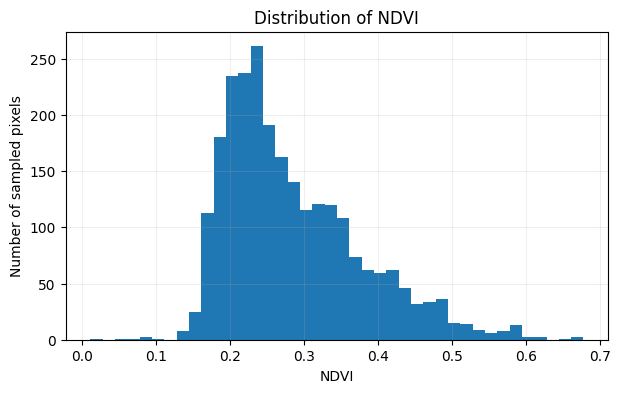

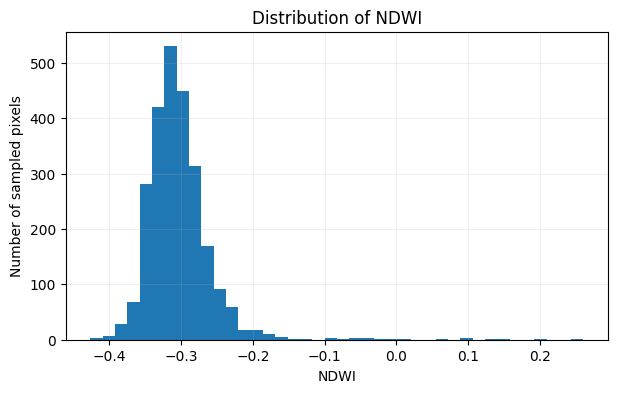

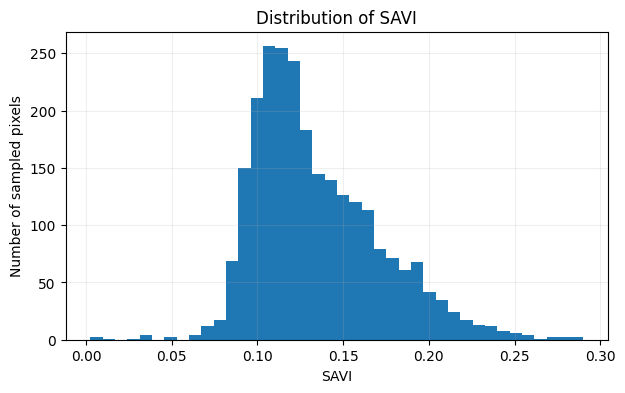

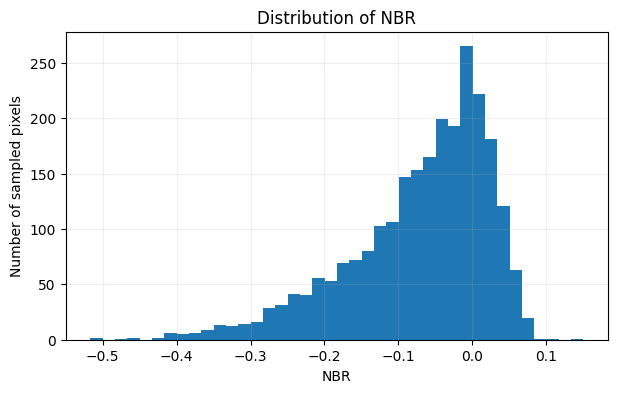

In [13]:
#plot a separate histogram for each index
for name in ["NDVI","NDWI","SAVI","NBR"]:
  plt.figure(figsize=(7,4))
  plt.hist(sample_df[name],bins =40)
  plt.xlabel(name)
  plt.ylabel("Number of sampled pixels")
  plt.title(f"Distribution of {name}")
  plt.grid(alpha=0.2)
  plt.show()

In [15]:
#statitable
sample_df["NDVI_minus_SAVI"] = sample_df["NDVI"] - sample_df["SAVI"]
comparison = sample_df[["NDVI","SAVI","NDVI_minus_SAVI"]].describe()
comparison

,NDVI,SAVI,NDVI_minus_SAVI
count,2500.000000,2500.000000,2500.000000
mean,0.284949,0.134436,0.150513
std,0.092494,0.036811,0.056757
min,0.010984,0.002472,0.008512
25%,0.215251,0.107365,0.107525
50%,0.260454,0.125461,0.134616
75%,0.337905,0.156238,0.182502
max,0.678009,0.290187,0.390277


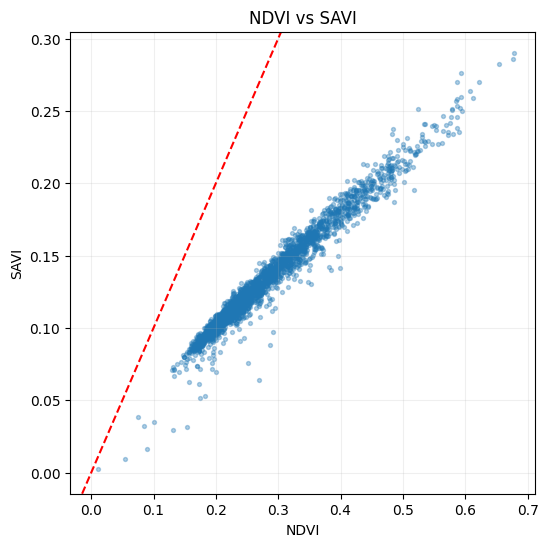

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(sample_df["NDVI"],sample_df["SAVI"],s=8 , alpha =0.35)
plt.xlabel("NDVI")
plt.ylabel("SAVI")
plt.title("NDVI vs SAVI")
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.grid(alpha=0.2)
plt.show()

In [17]:
# part H
vegetation__candidate = ndvi.gt(0.40).rename("Vegetation_candidate")
water_candidate = ndwi.gt(0.00).rename("Water_candidate")
MaskMap = geemap.Map()
MaskMap.centerObject(aoi,10)
MaskMap.addLayer(image.clip(aoi),true_color,"True colour",True)
MaskMap.addLayer(
    vegetation__candidate.selfMask().clip(aoi),
    {'palette': '00AA00'},
    'NDVI > 0.40',
    False,
)
MaskMap.addLayer(
    water_candidate.selfMask().clip(aoi),
    {'palette': '0000FF'},
    'NDWI > 0.00',
    False,
)
MaskMap

Map(center=[26.259898468514926, 82.06401801374203], controls=(WidgetControl(options=['position', 'transparent_…

In [19]:
export_indices = index_image.select(
    [
        'NDVI',
        'NDWI',
        'SAVI',
        'NBR',
    ]).clip(aoi)
task = ee.batch.Export.image.toDrive(
    image=export_indices,
    description = "Landsat8_spectral_Indices",
    folder ="Earth Engine",
    fileNamePrefix="Landsat8_NDVI_NDWI_SAVI_NBR",
    region=aoi,
    scale=30,
    maxPixels=1e9,
    fileFormat="GeoTIFF",
)
# task.start()

print("Export prepared .Uncomment task.start() to submit it.")

Export prepared .Uncomment task.start() to submit it.
